In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('/content/drive/MyDrive/aitrain/survey lung cancer.csv')

In [ ]:
from sklearn.preprocessing import OneHotEncoder
one=OneHotEncoder(sparse_output=False)
df['GENDER']=one.fit_transform(df[['GENDER']])
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,0.0,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,0.0,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,1.0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,0.0,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,1.0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [ ]:
df.tail()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
304,1.0,56,1,1,1,2,2,2,1,1,2,2,2,2,1,YES
305,0.0,70,2,1,1,1,1,2,2,2,2,2,2,1,2,YES
306,0.0,58,2,1,1,1,1,1,2,2,2,2,1,1,2,YES
307,0.0,67,2,1,2,1,1,2,2,1,2,2,2,1,2,YES
308,0.0,62,1,1,1,2,1,2,2,2,2,1,1,2,1,YES


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   GENDER                 309 non-null    float64
 1   AGE                    309 non-null    int64  
 2   SMOKING                309 non-null    int64  
 3   YELLOW_FINGERS         309 non-null    int64  
 4   ANXIETY                309 non-null    int64  
 5   PEER_PRESSURE          309 non-null    int64  
 6   CHRONIC DISEASE        309 non-null    int64  
 7   FATIGUE                309 non-null    int64  
 8   ALLERGY                309 non-null    int64  
 9   WHEEZING               309 non-null    int64  
 10  ALCOHOL CONSUMING      309 non-null    int64  
 11  COUGHING               309 non-null    int64  
 12  SHORTNESS OF BREATH    309 non-null    int64  
 13  SWALLOWING DIFFICULTY  309 non-null    int64  
 14  CHEST PAIN             309 non-null    int64  
 15  LUNG_C

In [ ]:
df.describe()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN
count,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,0.475728,62.673139,1.563107,1.569579,1.498382,1.501618,1.504854,1.673139,1.556634,1.556634,1.556634,1.579288,1.640777,1.469256,1.556634
std,0.500221,8.210301,0.496806,0.495938,0.500808,0.500808,0.500787,0.469827,0.497588,0.497588,0.497588,0.494474,0.480551,0.499863,0.497588
min,0.000000,21.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,0.000000,62.000000,2.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000
75%,1.000000,69.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,1.000000,87.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


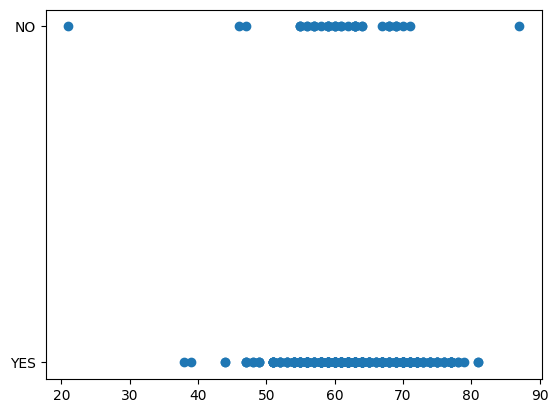

In [ ]:
x=df['AGE']
y=df['LUNG_CANCER']
plt.scatter(x, y)

In [ ]:
X=df[['SMOKING','CHRONIC DISEASE','ALCOHOL CONSUMING','SHORTNESS OF BREATH']]
y=df['LUNG_CANCER']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 1, test_size=0.2)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score
print("Accuracy:",accuracy_score(y_test, y_pred))

Accuracy: 0.8548387096774194


In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test)
mat = confusion_matrix(y_test,y_pred)
print(mat)
from sklearn.metrics import classification_report as cr
print(cr(y_test,y_pred))

[[ 0  8]
 [ 1 53]]
              precision    recall  f1-score   support

          NO       0.00      0.00      0.00         8
         YES       0.87      0.98      0.92        54

    accuracy                           0.85        62
   macro avg       0.43      0.49      0.46        62
weighted avg       0.76      0.85      0.80        62



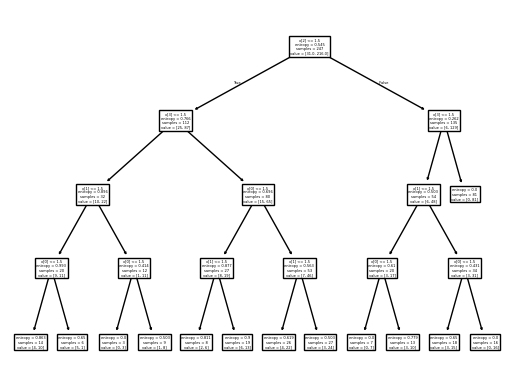

In [ ]:
from matplotlib import pyplot as plt
from sklearn import tree
fig=plt.figure()
tree.plot_tree(model)
plt.show()